# 📘Домашнє завдання №15 Основи часових рядів: компоненти, типи, проблеми

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW15

### Завдання 1. Побудова графіка

Побудуйте графік часового ряду.

**Потрібно визначити:**

* чи є тренд;
* чи є сезонність;
* чи помітні аномалії.

---

### Завдання 2. Пошук проблем у даних

Знайдіть у часовому ряді:

* пропущені значення
* аутлаєри
* можливий шум

---

### Завдання 3. Обробка пропусків

Заповніть пропущені значення одним із методів:

* інтерполяція
* середнє значення
* попереднє значення

Побудуйте графік після виправлення.

---

### Завдання 4. Обробка аутлаєрів

Знайдіть аномальні значення та:

* видаліть їх
  або
* замініть коректними значеннями

Побудуйте оновлений графік.

---

### Завдання 5. Виділення компонентів часового ряду

Використайте `seasonal_decompose()` та виділіть:

* trend
* seasonal
* residual

---

### Завдання 6. Ковзне середнє

Побудуйте:

* 7-денне ковзне середнє
* 30-денне ковзне середнє

Порівняйте результати, побудувавши відповідні графіки.

---

### Завдання 7. Експоненційне згладжування

Застосуйте експоненційне згладжування, побудувавши відповідні графіки.

Спробуйте різні значення параметра `alpha`:

* 0.2
* 0.5
* 0.8

Порівняйте результати.

In [23]:
# Silent installation or update

# Clean cache
!python3 -m pip cache purge -q

# Force updating
package_update = [
    "pip",
    "scikit-learn",
]

for package_name in package_update:
    !bash -c "python3 -m pip install -U '{package_name}' -q"

# Install missing packages
package_array = [
    "jinja2",
    "ipywidgets",
    "nbformat",
    "kagglehub[pandas-datasets]",
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
    "scipy-stubs",
]

for package_name in package_array:
    !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# Synchronization with remote source

import shutil
from pathlib import Path

# Input data
hm_version = 15

# Solution
git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}.git"
main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"

# upload all files
current_path = !pwd
current_path = current_path[0]
parent_path = !dirname "$current_path"
parent_path = parent_path[0]
temp_path = f"{parent_path}/temp"

# Clone data
!rm -rf "$temp_path"
!git clone "$git_project_url" "$temp_path"

source = Path(temp_path)
destination = Path(current_path)
exclude = {main_file_name, ".git", ".idea"}

for item in source.iterdir():
    if item.name in exclude:
        continue

    target = destination / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

# Clean temp folder
!rm -rf "$temp_path"

Cloning into '/Users/bohdanpinchuk/Documents/Data Science/Development/Data_Science/Practical_tasks/Homework_15/temp'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 26 (delta 4), reused 25 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 135.03 KiB | 1.34 MiB/s, done.
Resolving deltas: 100% (4/4), done.


## ✅ Рішення 1

Побудуйте графік часового ряду.

**Потрібно визначити:**

* чи є тренд;
* чи є сезонність;
* чи помітні аномалії.

In [3]:
# Data synthesis

import numpy as np
import pandas as pd
from IPython.display import display

# Input data
rng_seed = 42
use_sign = False

# Solution
np.random.seed(rng_seed)

# створюємо часову шкалу
dates = pd.date_range(start='2024-01-01', periods=365, freq='D')
# тренд
trend = np.linspace(100, 200, len(dates))
# сезонність
seasonality = 30 * np.sin(2 * np.pi * np.arange(len(dates)) / 30)
# шум
noise = np.random.normal(0, 10, len(dates))
# базовий ряд
sales = trend + seasonality + noise

# додаємо пропуски
missing_idx = np.asarray(np.random.choice(len(dates), size=15, replace=False))
sales[missing_idx] = np.nan

# додаємо аутлаєри
outlier_idx = np.asarray(np.random.choice(len(dates), size=10, replace=False))
sales[outlier_idx] *= 2.5

if use_sign:
    sales[outlier_idx] *= np.random.choice([1, -1], size=outlier_idx.size)

# створюємо DataFrame
df = pd.DataFrame({
    'date': dates,
    'sales': sales
})

# Print results
display(df)


,date,sales
0,2024-01-01,104.967142
1,2024-01-02,105.129433
2,2024-01-03,119.228435
3,2024-01-04,133.688032
4,2024-01-05,121.051712
...,...,...
360,2024-12-26,204.094564
361,2024-12-27,220.740564
362,2024-12-28,NaN
363,2024-12-29,221.375950


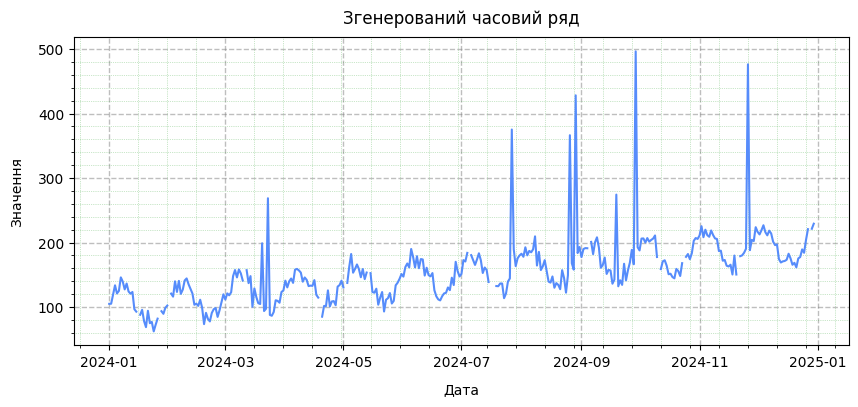

In [4]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["date"], df["sales"])

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Згенерований часовий ряд", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')

plt.show()

In [21]:
# Згладжування

import numpy as np
from scipy import signal

# Input data
window_size = 7

# Solution
temp_df = df.copy()
temp_df.dropna(inplace=True)
temp_df["id"] = temp_df.index

g_fun = np.ones(window_size) / window_size
f_fun = temp_df["sales"].values
smoothed_data = signal.fftconvolve(y_left, y_right, mode='same')

# Print results


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [13]:
# Аналіз наявності тренду

import apps.reporter as rpt
from sklearn.linear_model import LinearRegression

# Input data
rng_seed = 42

# Solution
temp_df = df.copy()
temp_df.dropna(inplace=True)
temp_df["id"] = temp_df.index

X_data = temp_df["id"].values.reshape(-1, 1)
Y_data = temp_df["sales"].values.reshape(-1, 1)

model_line = LinearRegression()
model_line.fit(X_data, Y_data)
beta0 = model_line.intercept_
beta1 = model_line.coef_[0]
beta1_deg = np.rad2deg(np.arctan(beta1))

Y_pred = model_line.predict(X_data)
temp_df["predicted"] = Y_pred

rp = rpt.Reporter()
rp.tolerance = 2
rp.add_item("Коефіцієнт β₀", f"{beta0.item(0):.6f}")
rp.add_item("Коефіцієнт β₁", f"{beta1.item(0):.6f}")
rp.add_item("Кут нахилу β₁", f"{beta1_deg.item(0):.2f}°")
rp.add_item("Наявність тренду", 'є' if beta0 > 0 else 'немає')

# Print results
rp.print_pd_report("Параметри лінійної регресії")

,date,sales,id,predicted
0,2024-01-01,104.967142,0,101.860378
1,2024-01-02,105.129433,1,102.152913
2,2024-01-03,119.228435,2,102.445447
3,2024-01-04,133.688032,3,102.737982
4,2024-01-05,121.051712,4,103.030517
...,...,...,...,...
359,2024-12-25,184.116713,359,206.880351
360,2024-12-26,204.094564,360,207.172886
361,2024-12-27,220.740564,361,207.465421
363,2024-12-29,221.375950,363,208.050490


Attribute,Result
Коефіцієнт β₀,101.860378
Коефіцієнт β₁,0.292535
Кут нахилу β₁,16.31°
Наявність тренду,є


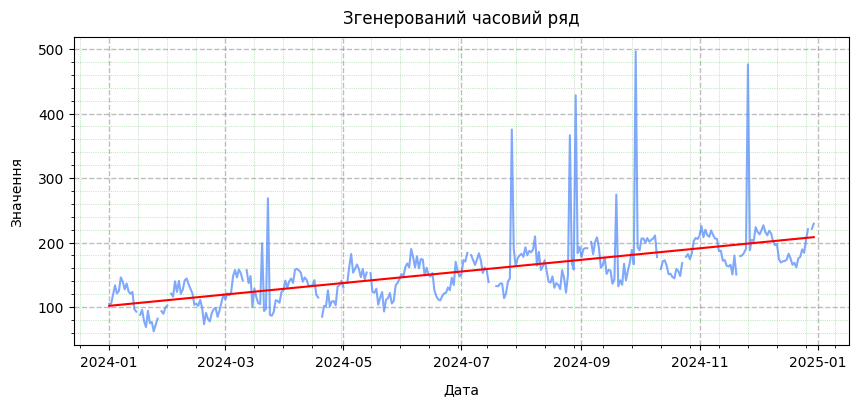

In [15]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["date"], df["sales"], alpha=0.75)
ax.plot(temp_df["date"], temp_df["predicted"], color='red')

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Згенерований часовий ряд", pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')

plt.show()